# **Modelado Pyspark - Click-Through Rate**

## **Importación librerías**

Se importan las librerías necesarias para el modelado, se importan herramientas para división de datos y  preprocesamiento.

In [51]:
import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import platform
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, col, when, hour
import pyspark
from pyspark.sql.functions import countDistinct
from pyspark.sql.types import IntegerType, DoubleType, StringType
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml import Pipeline
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import functions as F
import sys



## **Creación de la Sesión Spark y Carga del Dataset** 

Se inicia una sesión de Apache Spark configurada para ejecución local con 8 GB de memoria asignada, optimizando así el manejo de recursos para el procesamiento distribuido. 

In [52]:
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [53]:
print("Driver usando Python:", platform.python_version())
print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])

Driver usando Python: 3.9.23
PYSPARK_PYTHON: c:\Users\CRISTIAN\miniconda3\envs\ml_venv\python.exe


In [54]:
spark = SparkSession.builder \
    .appName("WSL Spark Demo") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [55]:
df_spark = spark.read.csv(os.path.join(os.getcwd(), r'datos\train\train.csv'), header=True, inferSchema=True)

### **Encabezado Dataframe**

In [56]:
df_spark.show(5)

+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|                  id|click|    hour|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|app_category|device_id|device_ip|device_model|device_type|device_conn_type|  C14|C15|C16| C17|C18|C19|   C20|C21|
+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
| 1000009418151094273|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    07d7df22| a99f214a| ddd2926e|    44956a24|          1|               2|15706|320| 50|1722|  0| 35|    -1| 79|
|10000169349117863715|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    

### **Tamaño Dataset**

In [57]:
df_spark.count()

40428967

Hasta ahora hemos trabajado con un subsample de 1 millón de registros para el modelado en Scikit-learn, lo que permitió agilizar el análisis exploratorio y la optimización de hiperparámetros. Sin embargo, el dataset completo cuenta con 40 millones de observaciones, lo que representa un incremento de 40 veces en volumen de datos.

Este aumento de escala motiva el uso de PySpark, ya que está diseñado para manejar grandes volúmenes de datos mediante procesamiento distribuido, optimizando el uso de memoria y tiempo de cómputo en entornos de big data.

### **Extracción y conversión de variables temporales**

Posteriormente, extraemos variables temporales específicas con el fin de analizar los datos con mayor detalle, para esto, creamos 4 nuevas variables que corresponden a: `dia`, `mes`, `año`, `hour`.  

In [58]:
df_spark = df_spark.withColumn(
    "datetime",
    to_timestamp(col("hour").cast("string"), "yyMMddHH")
)

In [59]:
df_spark = df_spark.withColumn(
    "hour",
    hour("datetime")
)

### **Elimininamos variables identificadoras**

In [60]:
df_spark = df_spark.drop('id','device_id','device_ip','app_id','site_id', 'datetime', 'C14')

In [61]:
df_spark.show(5)

+-----+----+----+----------+-----------+-------------+----------+------------+------------+-----------+----------------+---+---+----+---+---+------+---+
|click|hour|  C1|banner_pos|site_domain|site_category|app_domain|app_category|device_model|device_type|device_conn_type|C15|C16| C17|C18|C19|   C20|C21|
+-----+----+----+----------+-----------+-------------+----------+------------+------------+-----------+----------------+---+---+----+---+---+------+---+
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    44956a24|          1|               2|320| 50|1722|  0| 35|    -1| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    711ee120|          1|               0|320| 50|1722|  0| 35|100084| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    8a4875bd|          1|               0|320| 50|1722|  0| 35|100084| 79|
|    0|   0|1005|         0|   f3845767|     28905ebd|  7801e8d9|    07d7df22|    

### **Separación tipo de variables**

In [62]:
var_anon = ['C1','C15','C16','C17','C18','C19','C20','C21']
var_cat = ['banner_pos','site_domain','site_category','app_domain','app_category','device_type','device_model','device_conn_type','hour']

In [63]:
df_spark.printSchema()

root
 |-- click: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



### **Conversión a variables categóricas**

Se convierten las variables anónimas y categóricas al tipo `StringType()` dentro del DataFrame de PySpark. Esto asegura que sean tratadas correctamente como variables categóricas en las etapas posteriores de transformación y modelado.



In [64]:
for var in var_anon+var_cat:  
    df_spark = df_spark.withColumn(var, col(var).astype(StringType()))


In [65]:
df_spark.printSchema()

root
 |-- click: integer (nullable = true)
 |-- hour: string (nullable = true)
 |-- C1: string (nullable = true)
 |-- banner_pos: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- device_conn_type: string (nullable = true)
 |-- C15: string (nullable = true)
 |-- C16: string (nullable = true)
 |-- C17: string (nullable = true)
 |-- C18: string (nullable = true)
 |-- C19: string (nullable = true)
 |-- C20: string (nullable = true)
 |-- C21: string (nullable = true)



### **Agrupar variables de alta cardinalidad**

In [66]:
for col_name in df_spark.columns:
    n = df_spark.select(countDistinct(col_name)).collect()[0][0]
    print(col_name, n)

click 2
hour 24
C1 7
banner_pos 7
site_domain 7745
site_category 26
app_domain 559
app_category 36
device_model 8251
device_type 5
device_conn_type 4
C15 8
C16 9
C17 435
C18 4
C19 68
C20 172
C21 60


Para las variables con mayor cardinalidad `device_model`, `site_domain` y `C17`, se identifican aquellas categorías con menos de 20,000 ocurrencias y se agrupan bajo la etiqueta `'OTHER'`. Esta transformación reduce la dimensionalidad y evita que categorías con pocas observaciones generen estimaciones inestables en etapas posteriores de modelado, manteniendo únicamente las categorías más representativas.



In [ ]:
for var in ['device_model', 'site_domain', 'C17']:

    freq = df_spark.groupBy(var).count()

    rare = freq.filter(col("count") < 20000).select(var)
    rare_list = [row[var] for row in rare.collect()]

    df_spark = df_spark.withColumn(
        var,
        when(col(var).isin(rare_list), "OTHER").otherwise(col(var))
    )

In [68]:
for col_name in df_spark.columns:
    n = df_spark.select(countDistinct(col_name)).collect()[0][0]
    print(col_name, n)

click 2
hour 24
C1 7
banner_pos 7
site_domain 93
site_category 26
app_domain 559
app_category 36
device_model 285
device_type 5
device_conn_type 4
C15 8
C16 9
C17 201
C18 4
C19 68
C20 172
C21 60


## **Separación conjunto Train - Test**

Se divide el conjunto de datos en dos particiones: 80% para entrenamiento y 20% para prueba, utilizando `randomSplit` con semilla 42 para garantizar reproducibilidad.

In [69]:
df_spark = df_spark.cache()

train_data, test_data = df_spark.randomSplit([0.8, 0.2], seed=42)

print(f"Tamaño train: {train_data.count()}, test: {test_data.count()}")

Tamaño train: 32344946, test: 8084021


## **Validación de la distribución de clases**

Se verifica que la división entre Train y Test mentangan la proporción original de la variable objetivo `click`.

In [70]:
print("Distribución en train:")
train_dist = train_data.groupBy("click").count().toPandas()
print(train_dist)

print("\nDistribución en test:")
test_dist = test_data.groupBy("click").count().toPandas()  
print(test_dist)

Distribución en train:
   click     count
0      1   5494661
1      0  26850285

Distribución en test:
   click    count
0      1  1370405
1      0  6713616


* `Train`: 26.85M de no clicks (80%) y 5.49M de clicks (20%)

* `Test`: 6.71M de no clicks (80%) y 1.37M de clicks (20%)

Ambos conjuntos conservan la misma distribución de clases (80% - 20%), lo que indica que la partición aleatoria es representativa del conjunto original.

## **Preprocesamiento variables**

In [71]:
vars_categoricas = var_cat + var_anon 

indexers = [
    StringIndexer(inputCol=col, outputCol=f'{col}_idx', handleInvalid='keep')
    for col in vars_categoricas
]

idx_cols = [f'{col}_idx' for col in vars_categoricas]
final_assembler = VectorAssembler(
    inputCols=idx_cols,
    outputCol='features'
)

 A diferencia de Scikit-learn, donde se utilizó `Target Encoding` para codificar las categorías en función de la variable objetivo, PySpark no cuenta con una implementación nativa de este método. Como alternativa, y con el objetivo de no aumentar la dimensionalidad del dataset evitando `One Hot Encoding`, se opta por utilizar `StringIndexer`, que asigna un índice numérico a cada categoría.

`StringIndexer` convierte las categorías en índices numéricos. El parámetro `handleInvalid='keep'` permite manejar valores no vistos durante el entrenamiento, asignándoles un índice especial.

## **Pipeline**

In [72]:
prep_pipeline = Pipeline(stages=indexers + [final_assembler])
prep_model = prep_pipeline.fit(train_data)
sample = prep_model.transform(train_data.limit(1))
num_features = len(sample.select('features').first()[0])
print(f"Número de features: {num_features}")

Número de features: 17


El pipeline se entrena por medio de `fit` sobre el conjunto de entrenamiento y se aplica una transformación de prueba sobre una muestra para verificar el resultado. Se extrae el número de features generado, que corresponde a la cantidad total de columnas indexadas ingresadas al ensamblador. 

## **Configuración de hiperparámetros**

Se define una configuración inicial para la red neuronal en PySpark tomando como referencia los mejores hiperparámetros obtenidos durante la optimización con Scikit-learn.

* `layers`: 

    * `num_features`: capa de entrada con la dimensión del vector de características.

    * `100` y `50`: dos hidden layer con 100 y 50 neuronas respectivamente. 

    * `2`: output layer con 2 neuronas para clasificación binaria.
 
* `stepSize`: Tasa de aprendizaje inicial de 0.001. Cabe aclarar que en Scikit-learn el parámetro `alpha` corresponde a regularización, no a la tasa de aprendizaje, por lo que este parámetro no es equivalente (PySpark no cuenta con parámetro de regularización).

* `maxIter`: Número máximo de iteraciones fijado en 100, manteniendo el mismo valor que en la mejor configuración de Scikit-learn.

In [ ]:
configs = [
    {'layers': [num_features, 100, 50, 2], 'stepSize': 0.001, 'maxIter': 100},
]


## **Entrenamiento y métricas de evaluación**

In [74]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol='click',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

evaluator_precision = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='precisionByLabel')
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='recallByLabel')
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='click', predictionCol='prediction', metricName='fMeasureByLabel')

results = []

for config in configs:
    print(f"\nEntrenando: {config}")

    mlp = MultilayerPerceptronClassifier(
        layers=config['layers'],
        stepSize=config['stepSize'],
        maxIter=config['maxIter'],
        solver='gd',
        labelCol='click',
        featuresCol='features',
        seed=42
    )

    full_pipeline = Pipeline(stages=indexers + [final_assembler, mlp])

    start_train = time.time()
    model = full_pipeline.fit(train_data)
    train_time = time.time() - start_train

    start_pred = time.time()
    predictions = model.transform(test_data)
    pred_time = time.time() - start_pred

    auc       = evaluator_auc.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions, {evaluator_precision.metricLabel: 1.0})
    recall    = evaluator_recall.evaluate(predictions, {evaluator_recall.metricLabel: 1.0})
    f1        = evaluator_f1.evaluate(predictions, {evaluator_f1.metricLabel: 1.0})

    results.append({
        'layers': config['layers'],
        'stepSize': config['stepSize'],
        'maxIter': config['maxIter'],
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time,
        'pred_time': pred_time
    })

    print(f"AUC: {auc:.4f} | P: {precision:.4f} | R: {recall:.4f} | F1: {f1:.4f} | "
          f"Train: {train_time:.1f}s | Pred: {pred_time:.1f}s")

    predictions.groupBy('click', 'prediction').count().show()


Entrenando: {'layers': [17, 100, 50, 2], 'stepSize': 0.001, 'maxIter': 100}
AUC: 0.5280 | P: 0.1420 | R: 0.0000 | F1: 0.0000 | Train: 3732.6s | Pred: 0.7s
+-----+----------+-------+
|click|prediction|  count|
+-----+----------+-------+
|    1|       0.0|1370382|
|    0|       0.0|6713477|
|    1|       1.0|     23|
|    0|       1.0|    139|
+-----+----------+-------+



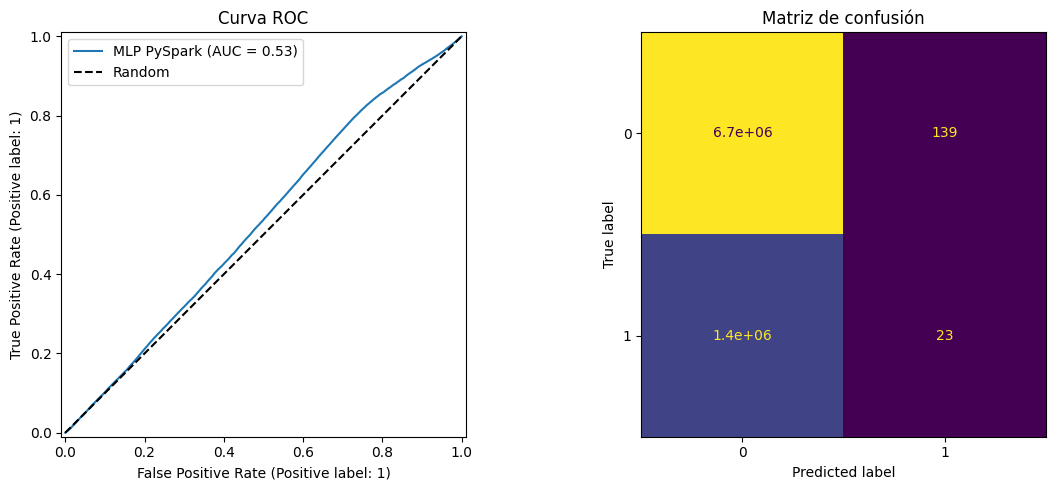

In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

results_df = predictions.select(
    'click',
    'prediction',
    'probability'
).toPandas()

y_true = results_df['click'].values
y_pred_spark = results_df['prediction'].values
y_prob_spark = np.array(results_df['probability'].tolist())[:, 1] 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_true, y_prob_spark,
    ax=axes[0],
    name='MLP PySpark'
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('Curva ROC')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_spark,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

**Métricas de rendimiento**:

* `AUC`: 0.5280, muy cercano a 0.5 (clasificador aleatorio), indicando que el modelo no logra discriminar entre clases.

* `Precisión`: 0.1420, baja.

* `Recall`: 0.0000, el modelo prácticamente no detecta ningún clic positivo.

* `F1-score`: 0.0000, reflejo del recall nulo.

**Matriz de confusión:**

* `Verdaderos negativos`: 6,713,477

* `Falsos positivos`: 139

* `Falsos negativos`: 1,370,382

* `Verdaderos positivos`: 23

El modelo en PySpark presenta un rendimiento muy pobre, prácticamente nulo para detectar la clase minoritaria.

## **Interpretabilidad con LIME**

In [ ]:
import lime
import lime.lime_tabular

predictions_df = predictions.select('click', 'prediction', 'features').toPandas()

features_array = np.array(predictions_df['features'].tolist())
y_pred_array   = predictions_df['prediction'].values
y_test_array   = predictions_df['click'].values

train_transformed = model.transform(train_data.limit(10000)).select('features').toPandas()
X_train_array = np.array(train_transformed['features'].tolist())

mal_clasificados = np.where(y_pred_array != y_test_array)[0]
idx = mal_clasificados[0]

print(f"Índice: {idx}")
print(f"Valor real: {y_test_array[idx]}")
print(f"Valor predicho: {y_pred_array[idx]}")

def predict_fn(data):
    from pyspark.ml.linalg import Vectors
    rows = [{'features': Vectors.dense(row)} for row in data]
    spark_df = spark.createDataFrame(rows)
    
    mlp_stage = model.stages[-1] 
    preds = mlp_stage.transform(spark_df).select('probability').toPandas()
    return np.array(preds['probability'].tolist())

Índice: 108886
Valor real: 0
Valor predicho: 1.0


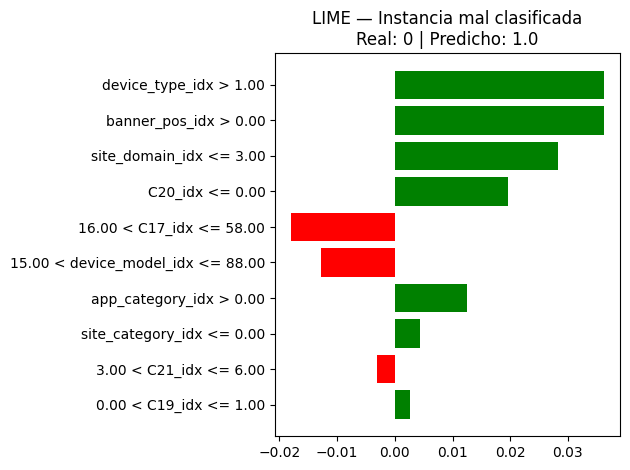

In [ ]:
feature_names = [f'{col}_idx' for col in vars_categoricas]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=feature_names,
    class_names=['no click', 'click'],
    mode='classification',
    random_state=42
)

exp = explainer.explain_instance(
    data_row=features_array[idx],
    predict_fn=predict_fn,
    num_features=10
)

fig = exp.as_pyplot_figure()
plt.title(f"LIME — Instancia mal clasificada\nReal: {y_test_array[idx]} | Predicho: {y_pred_array[idx]}")
plt.tight_layout()
plt.show()

### **Interpretación**

Las tres variables con mayor impacto en la predicción son:

* `device_type_idx`: La categoría de tipo de dispositivo es la variable más influyente, con un impacto positivo de +0.030 cuando supera cierto umbral, indicando que algunos dispositivos tienen mayor propensión a clicks.

* `banner_pos_idx`: La posición del banner publicitario ocupa el segundo lugar, con un efecto positivo de +0.025, sugiriendo que ciertas ubicaciones del anuncio favorecen la interacción.

* `site_domain_idx`: El dominio del sitio web aporta +0.020 cuando se encuentra por debajo de un punto de corte específico, lo que indica que el modelo atribye la proprensión del click a sitios particulares.

La mayoría de variables cuentan con impacto positivo (color verde) `device_type_idx` > 1.00 (+0.030): tipos de dispositivo tienen mayor propensión a click, `banner_pos_idx` > 0.00 (+0.025): posición del banner influye positivamente, `site_domain_idx` <= 3.00 (+0.020): dominios específicos asociados a más clics, `C20_idx` <= 0.00 (+0.015): variable anónima con efecto positivo.

Son pocas las variables con impacto negativo (color rojo) `C17_idx` entre 16 y 58 (-0.010): rango específico de esta variable anónima reduce clicks, `device_model_idx` entre 15 y 88 (-0.012): modelos de dispositivo en este rango tienen menor tasa de clicks, `C21_idx` entre 3 y 6 (-0.003): variable anónima con efecto negativo leve.

# **Conclusiones**


### **Tabla comparativa**

| Métrica                      | Scikit-learn                     | PySpark                               |
|------------------------------|----------------------------------|---------------------------------------|
| AUC                          | 0.7250                           | 0.5280                                |
| Precisión                    | 0.60                             | 0.1420                                |
| Recall                       | 0.06                             | 0.0000                                |
| F1-score                     | 0.10                             | 0.0000                                |
| Método de encoding           | Target Encoding (con suavizado)  | StringIndexer + VectorAssembler       |
| Tratamiento categorías raras | Agrupación en OTHER (umbral 5000)| Agrupación en OTHER (umbral 20000)    |
| Tamaño de datos              | 1M registros (subsample)         | 40M registros (completo)              |
| Tiempo de entrenamiento      | 1,801.6 s (30 min)               | 3,732.6 s (62 min)                    |

**Análisis de resultados:**

* Scikit-learn logró un rendimiento moderado en la detección de clics (recall 6%, precisión 60%), con un AUC aceptable de 0.725, gracias al uso de `Target Encoding` y la posibilidad de ajustar finamente hiperparámetros y estrategias de regularización.

* PySpark, a pesar de procesar el dataset completo de 40M registros, presentó un rendimiento prácticamente nulo para la clase minoritaria (recall 0%, precisión 14%), lo que indica que no logró aprender patrones predictivos para los clics.

**Ventajas y limitaciones de cada enfoque:**

Scikit-learn ofrece mayor flexibilidad y variedad de técnicas para el preprocesamiento y encoding (`Target Encoding`, `One Hot Encoding`, `Label Enconding`), así como una amplia gama de métricas y métodos de optimización. Sin embargo, no escala a volúmenes de 40M registros de manera eficiente.

PySpark destaca en la lectura, visualización y manipulación de datasets masivos. No obstante, sus opciones de encoding son limitadas (principalmente `StringIndexer` y `OneHotEncoder`). Además, los modelos disponibles tienen menos parámetros ajustables en comparación con Scikit-learn, lo que dificulta replicar estrategias exitosas como `Target Encoding`.


Como conlusión final, para proyectos con datasets masivos, lo más recomendable es entrenar el modelo sobre un subsample representativo que permita aprovechar la riqueza de técnicas y configuraciones disponibles en entornos como Scikit-learn. Una vez validado el modelo, se puede implementar en PySpark para predicción en producción sobre el volumen completo de datos, combinando así lo mejor de ambos mundos: la potencia analítica de Scikit-learn y la escalabilidad de PySpark.

